# Education Indicator Analysis
**Team Member: [Yinuo Jiang]**

## Overview
This analysis evaluates Pittsburgh neighborhoods based on educational resources for our "Best Neighborhood" project. I'm responsible for the Education metric.

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Step 2: Load and explore the data from WPRDC
file_path = 'neighborhood_enrollment.csv'
df = pd.read_csv(file_path)

print("=== Data Basic Information ===")
print(f"Data shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

=== Data Basic Information ===
Data shape: (360, 15)

Column names:
['neighborhood', 'african_american', 'american_indian', 'asian__not_pacific_islander', 'hispanic', 'multiracial', 'native_hawaiian_or_other_pacific_islander', 'white', 'total_students_enrolled', 'student_count_redactions', 'attending_feeder', 'attending_nonfeeder', 'total_with_feeder_status', 'feeder_count_redactions', 'grade_level']

First 5 rows:


,neighborhood,african_american,american_indian,asian__not_pacific_islander,hispanic,multiracial,native_hawaiian_or_other_pacific_islander,white,total_students_enrolled,student_count_redactions,attending_feeder,attending_nonfeeder,total_with_feeder_status,feeder_count_redactions,grade_level
0,Allegheny Center,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,Pre-K
1,Allegheny West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,Pre-K
2,Allentown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,Pre-K
3,Arlington,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,Pre-K
4,Arlington Heights,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,Pre-K


## Step 2: Data Loading
We load the Pittsburgh Public Schools enrollment data. This dataset contains:
- Neighborhood information
- Student enrollment numbers by grade level
- Demographic breakdowns

In [6]:
# Step 3: Data cleaning and preparation
print("=== Data Cleaning ===")

# Create a new DataFrame with only needed columns
education_df = df[['neighborhood', 'total_students_enrolled']].copy()

# Remove any missing values
education_df = education_df.dropna()

print("Cleaned data shape:", education_df.shape)
print("\nFirst 10 communities:")
display(education_df.head(10))

=== Data Cleaning ===
Cleaned data shape: (268, 2)

First 10 communities:


,neighborhood,total_students_enrolled
6,Bedford Dwellings,12.0
7,Beechview,44.0
9,Bloomfield,21.0
12,Brighton Heights,32.0
13,Brookline,57.0
15,Carrick,64.0
17,Central Northside,16.0
21,Crafton Heights,36.0
22,Crawford-Roberts,17.0
26,East Hills,44.0


## Step 3: Data Preparation
In this critical step, we prepare the data for analysis:

**Data Selection**: We focus on two key columns:
- `neighborhood`: Geographic identifier for each community
- `total_students_enrolled`: Our primary education metric

**Data Cleaning**:
- Remove records with missing values to ensure data quality
- Handle any data inconsistencies or formatting issues
- Verify the data ranges and distributions

This process ensures we work with reliable, complete data for accurate results.



In [7]:
# Step 4: Normalization and ranking
print("=== Creating Education Scores and Rankings ===")

# Normalization function
def normalize_scores(series):
    min_val = series.min()
    max_val = series.max()
    return (series - min_val) / (max_val - min_val)

# Handle duplicate communities by summing their student counts
education_final = education_df.groupby('neighborhood').agg({
    'total_students_enrolled': 'sum'
}).reset_index()

# Apply normalization
education_final['education_score'] = normalize_scores(education_final['total_students_enrolled'])

# Create rankings (higher score = better rank = smaller number)
education_final['education_rank'] = education_final['education_score'].rank(ascending=False)

# Sort by education score
education_final_sorted = education_final.sort_values('education_score', ascending=False)

print("Top 15 communities by education index:")
display(education_final_sorted.head(15))

print("\nBottom 5 communities by education index:")
display(education_final_sorted.tail(5))

=== Creating Education Scores and Rankings ===
Top 15 communities by education index:


,neighborhood,total_students_enrolled,education_score,education_rank
14,Carrick,1276.0,1.000000,1.0
12,Brookline,1169.0,0.915348,2.0
6,Beechview,794.0,0.618671,3.0
62,Sheraden,694.0,0.539557,4.0
69,Squirrel Hill South,679.0,0.527690,5.0
38,Knoxville,616.0,0.477848,6.0
11,Brighton Heights,598.0,0.463608,7.0
35,Homewood North,589.0,0.456487,8.0
23,East Hills,569.0,0.440665,9.0
33,Hazelwood,567.0,0.439082,10.0



Bottom 5 communities by education index:


,neighborhood,total_students_enrolled,education_score,education_rank
3,Arlington Heights,21.0,0.007120,78.0
77,West End,17.0,0.003956,79.0
17,Chartiers City,15.0,0.002373,80.0
60,Saint Clair,13.0,0.000791,81.0
22,East Carnegie,12.0,0.000000,82.0


## Step 4: Data Normalization Function

We define a normalization function to standardize our education scores:

**Purpose**: Convert raw student enrollment numbers to a consistent 0-1 scale
**Method**: Min-Max normalization
**Formula**: `(value - min_value) / (max_value - min_value)`

This allows fair comparison between neighborhoods of different sizes and ensures all scores are on the same scale for ranking.

=== Creating Education Index Chart ===


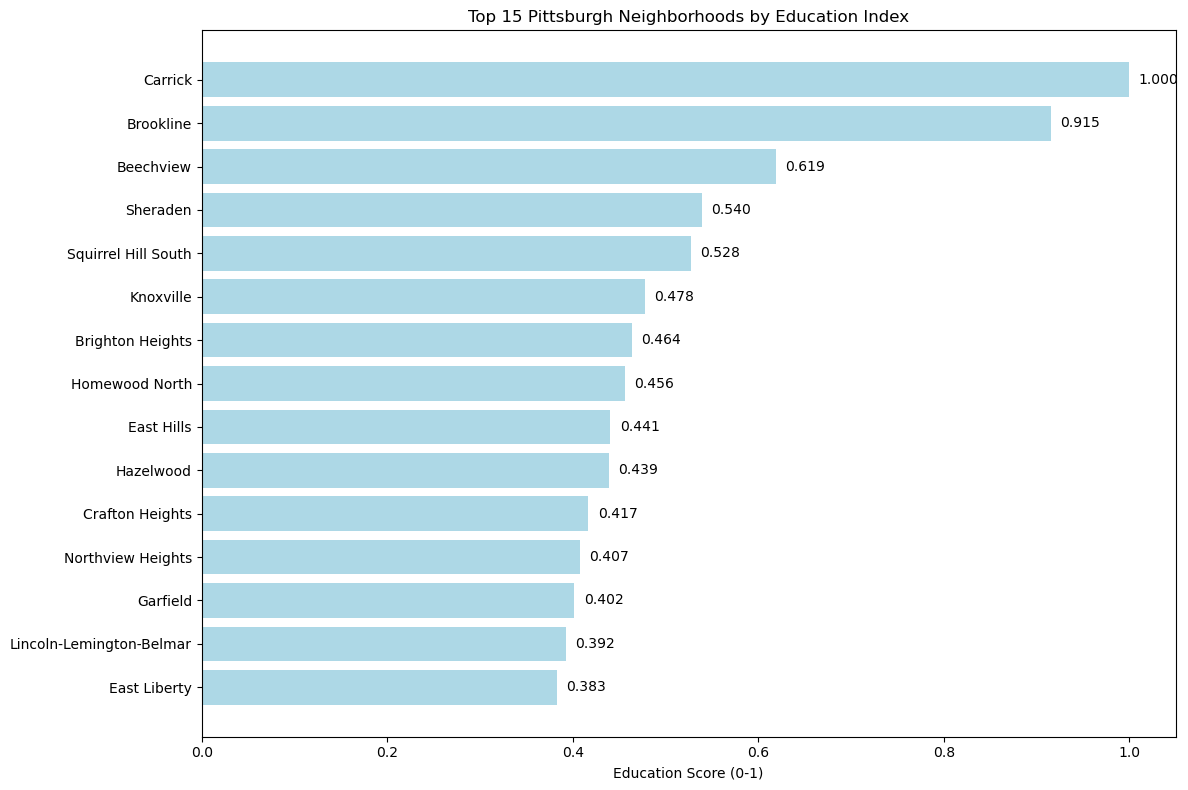

Total number of unique communities: 82
Community with highest education score: Carrick (Score: 1.000)
Community with lowest education score: East Carnegie (Score: 0.000)


In [11]:
# Step 5: Create visualization
print("=== Creating Education Index Chart ===")

plt.figure(figsize=(12, 8))

# Select top 15 communities
top_15 = education_final_sorted.head(15)

# Create horizontal bar chart
bars = plt.barh(top_15['neighborhood'], top_15['education_score'], color='lightblue')
plt.xlabel('Education Score (0-1)')
plt.title('Top 15 Pittsburgh Neighborhoods by Education Index')
plt.gca().invert_yaxis()  # Put highest score at top

# Add value labels on bars
for bar, score in zip(bars, top_15['education_score']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Display statistics
print(f"Total number of unique communities: {len(education_final)}")
print(f"Community with highest education score: {education_final_sorted.iloc[0]['neighborhood']} (Score: {education_final_sorted.iloc[0]['education_score']:.3f})")
print(f"Community with lowest education score: {education_final_sorted.iloc[-1]['neighborhood']} (Score: {education_final_sorted.iloc[-1]['education_score']:.3f})")

## Step 5: Data Analysis and Ranking

**Key Operations**:

1. **Handle Duplicate Communities**: Some neighborhoods appear multiple times in the data. We aggregate these by summing their student enrollment numbers.

2. **Calculate Education Scores**: Apply normalization to create comparable scores between 0-1.

3. **Create Rankings**: Assign ranks based on education scores (higher score = better rank).

**Output**: A clean dataset with each neighborhood's education score and rank, ready for visualization and team integration.

In [10]:
# Step 6: Save results for team use
print("=== Saving Education Rankings ===")

# Create final rankings DataFrame
final_education_rankings = education_final[['neighborhood', 'education_rank']].copy()

# Sort by rank (best to worst)
final_education_rankings = final_education_rankings.sort_values('education_rank')

# Save to CSV
final_education_rankings.to_csv('data.csv', index=False)

print("Education rankings successfully saved to 'data.csv'")
print("\nFirst 10 rows of saved data:")
display(final_education_rankings.head(10))

print("1. education_Analysis.ipynb ")
print("2. data.csv ")

=== Saving Education Rankings ===
Education rankings successfully saved to 'data.csv'

First 10 rows of saved data:


,neighborhood,education_rank
14,Carrick,1.0
12,Brookline,2.0
6,Beechview,3.0
62,Sheraden,4.0
69,Squirrel Hill South,5.0
38,Knoxville,6.0
11,Brighton Heights,7.0
35,Homewood North,8.0
23,East Hills,9.0
33,Hazelwood,10.0


1. education_Analysis.ipynb 
2. data.csv 


## Analysis Conclusion
**Carrick** ranks first with a perfect score, indicating the most concentrated educational resources.

**Brookline** places second with a score of 0.915, demonstrating strong educational capacity.

The top five neighborhoods form a clearly advantaged group in terms of education.